# Priority marker and homolog review

## tl;dr

This notebook reviews the top Pristina markers supporting the three
priority candidate correspondences. It is intended for choosing a short
validation panel, not for automatically transferring cell-type names.

## Context & Methods

The input table contains differentially expressed Pristina markers and
their top BLAST-supported human and zebrafish candidate homologs.
Functional descriptions are Ensembl REST annotations. A BLAST hit is a
homology candidate, not proof of orthology or conserved function.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "public_results").exists():
    ROOT = ROOT.parent
PUBLIC = ROOT / "public_results"

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Data

In [2]:
markers = pd.read_csv(PUBLIC / "priority_marker_validation.csv")
markers[[
    "pristina_cell_type", "marker_rank", "pristina_gene",
    "human_gene_symbol", "zebrafish_gene_symbol", "logfoldchanges", "pvals_adj",
]].head(12)

,pristina_cell_type,marker_rank,pristina_gene,human_gene_symbol,zebrafish_gene_symbol,logfoldchanges,pvals_adj
0,anterior intestine,1.0,PrileiEVm021040t1,CALM3,calm3a,5.128092,1.009068e-257
1,anterior intestine,2.0,PrileiEVm010796t1,FAR1,far1,9.248882,2.431898e-144
2,anterior intestine,4.0,PrileiEVm012003t1,PLB1,plb1,7.555562,1.580055e-93
3,anterior intestine,5.0,PrileiEVm012971t1,TNC,fgl2b,8.509220,9.190253e-93
4,anterior intestine,6.0,PrileiEVm005677t1,ACSBG1,acsbg2,6.092123,1.105753e-89
5,anterior intestine,11.0,PrileiEVm006191t1,SLC6A9,NaN,4.798564,2.127008e-48
6,anterior/mid-intestine 2,1.0,PrileiEVm014681t1,CTSL,ctsla,12.086677,4.076673e-202
7,anterior/mid-intestine 2,2.0,PrileiEVm011523t1,FUCA2,NaN,6.979238,5.909745e-98
8,anterior/mid-intestine 2,3.0,PrileiEVm008813t1,HEXB,hexb,6.901212,3.650218e-87
9,anterior/mid-intestine 2,4.0,PrileiEVm002679t1,MAN2B1,man2b1,7.200778,6.642601e-86


## Results

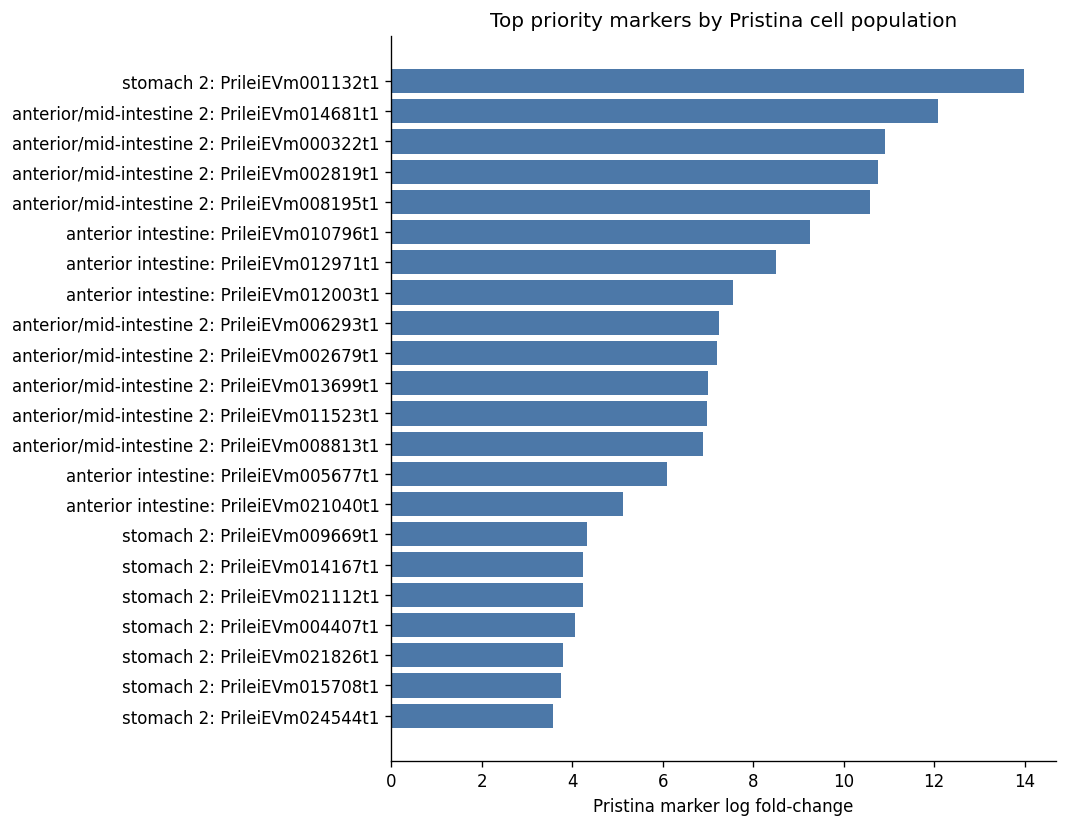

In [3]:
top = markers.loc[markers["marker_rank"] <= 10].copy()
top["label"] = top["pristina_cell_type"] + ": " + top["pristina_gene"]
top = top.sort_values("logfoldchanges")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["label"], top["logfoldchanges"], color="#4C78A8")
ax.set_xlabel("Pristina marker log fold-change")
ax.set_title("Top priority markers by Pristina cell population")
fig.tight_layout()
plt.show()

In [4]:
review = markers[[
    "pristina_cell_type", "marker_rank", "pristina_gene",
    "human_gene_symbol", "human_description",
    "zebrafish_gene_symbol", "zebrafish_description", "interpretation_note",
]].sort_values(["pristina_cell_type", "marker_rank"])
review.head(20)

,pristina_cell_type,marker_rank,pristina_gene,human_gene_symbol,human_description,zebrafish_gene_symbol,zebrafish_description,interpretation_note
0,anterior intestine,1.0,PrileiEVm021040t1,CALM3,calmodulin 3 [Source:HGNC Symbol;Acc:HGNC:1449],calm3a,"calmodulin 3a (phosphorylase kinase, delta) [S...",Candidate homology from top reciprocal BLAST-t...
1,anterior intestine,2.0,PrileiEVm010796t1,FAR1,fatty acyl-CoA reductase 1 [Source:HGNC Symbol...,far1,fatty acyl CoA reductase 1 [Source:ZFIN;Acc:ZD...,Candidate homology from top reciprocal BLAST-t...
2,anterior intestine,4.0,PrileiEVm012003t1,PLB1,phospholipase B1 [Source:HGNC Symbol;Acc:HGNC:...,plb1,phospholipase B1 [Source:ZFIN;Acc:ZDB-GENE-120...,Candidate homology from top reciprocal BLAST-t...
3,anterior intestine,5.0,PrileiEVm012971t1,TNC,tenascin C [Source:HGNC Symbol;Acc:HGNC:5318],fgl2b,fibrinogen-like 2b [Source:ZFIN;Acc:ZDB-GENE-1...,Candidate homology from top reciprocal BLAST-t...
4,anterior intestine,6.0,PrileiEVm005677t1,ACSBG1,acyl-CoA synthetase bubblegum family member 1 ...,acsbg2,acyl-CoA synthetase bubblegum family member 2 ...,Candidate homology from top reciprocal BLAST-t...
5,anterior intestine,11.0,PrileiEVm006191t1,SLC6A9,solute carrier family 6 member 9 [Source:HGNC ...,NaN,solute carrier family 6 member 5 [Source:NCBI ...,Candidate homology from top reciprocal BLAST-t...
6,anterior/mid-intestine 2,1.0,PrileiEVm014681t1,CTSL,cathepsin L [Source:HGNC Symbol;Acc:HGNC:2537],ctsla,cathepsin La [Source:ZFIN;Acc:ZDB-GENE-030131-...,Candidate homology from top reciprocal BLAST-t...
7,anterior/mid-intestine 2,2.0,PrileiEVm011523t1,FUCA2,alpha-L-fucosidase 2 [Source:HGNC Symbol;Acc:H...,NaN,alpha-L-fucosidase 2 [Source:NCBI gene (former...,Candidate homology from top reciprocal BLAST-t...
8,anterior/mid-intestine 2,3.0,PrileiEVm008813t1,HEXB,hexosaminidase subunit beta [Source:HGNC Symbo...,hexb,hexosaminidase B (beta polypeptide) [Source:ZF...,Candidate homology from top reciprocal BLAST-t...
9,anterior/mid-intestine 2,4.0,PrileiEVm002679t1,MAN2B1,mannosidase alpha class 2B member 1 [Source:HG...,man2b1,"mannosidase, alpha, class 2B, member 1 [Source...",Candidate homology from top reciprocal BLAST-t...


## Takeaways

- The anterior/mid-intestine 2 marker set contains a coherent
  lysosomal/catabolic program, which is consistent with its zebrafish
  LRE mapping hypothesis.
- The stomach 2 and anterior-intestine candidates require more specific
  marker confirmation because some leading genes are broadly expressed
  metabolic or housekeeping genes.
- Use the reviewed table to select targets for spatial or in situ
  experiments, while checking each gene's expression pattern directly
  in the Pristina atlas.